<a href="https://colab.research.google.com/github/Anashrah/Image-Caption-Generator/blob/main/Image_Caption_Generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📹 **IMAGE CAPTION GENERATOR — ITAI 1378 | GROUP 22600**

 **Team:** *Wayne Lu, Blessing Ajughu, Jaqueline Lomas Vazquez, Anashrah Adil, Emaan Gohar*

**Model:** *BLIP (Salesforce/blip-image-captioning-base)*

 **Dataset:** *COCO 2017 via Kaggle (nikhil7280/coco-image-caption)*




✅  **Install packages**

---

*Installs every library the project needs before anything else runs.*

In [1]:

!pip install -q transformers datasets pycocotools rouge-score \
    nltk evaluate sacrebleu pycocoevalcap Pillow

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 7.8 MB/s eta 0:00:00


✅ **Imports & random seed**

---


*Loads all Python libraries and fixes the random seed so
results are the same every time the notebook is run*



In [3]:
import os, json, random, math, zipfile, urllib.request
from pathlib import Path
from PIL import Image
import numpy as np

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    get_linear_schedule_with_warmup,
)

import nltk
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

# Fix random seed for reproducibility across numpy, python, and pytorch
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use GPU if available, otherwise fall back to CPU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cpu


✅ **Mount Google Drive**

---

*Connects Google Drive so saved checkpoints and results are not lost when the Colab session ends.*


In [4]:
from google.colab import drive
drive.mount("/content/drive")

SAVE_DIR = Path("/content/drive/MyDrive/caption_project")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print("Checkpoints will be saved to:", SAVE_DIR)

Mounted at /content/drive
Checkpoints will be saved to: /content/drive/MyDrive/caption_project


✅ **Download COCO dataset from Kaggle**

---

*Uploads your kaggle.json API key, then downloads the exact dataset linked in the project proposal using the Kaggle CLI.*

In [5]:
import os, json
from pathlib import Path
from google.colab import userdata

!pip install -q kaggle

# Read credentials from Colab Secrets
# Never hardcoded — safe to screen share
KAGGLE_USERNAME = userdata.get("KAGGLE_USERNAME")
KAGGLE_KEY      = userdata.get("KAGGLE_KEY")

# Create kaggle.json from the secrets
kaggle_dir = Path.home() / ".kaggle"
kaggle_dir.mkdir(exist_ok=True)

kaggle_creds = {"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}
kaggle_json  = kaggle_dir / "kaggle.json"

with open(kaggle_json, "w") as f:
    json.dump(kaggle_creds, f)

# Secure the file so Kaggle CLI accepts it
os.chmod(kaggle_json, 0o600)
print("Kaggle credentials loaded from secrets successfully.")

# Download the exact dataset from the proposal
# Source: https://www.kaggle.com/datasets/nikhil7280/coco-image-caption
!kaggle datasets download -d nikhil7280/coco-image-caption \
    --unzip -p /content/coco

print("Download complete.")

# Check folder structure so we know what paths to use in Cell 5
for root, dirs, files_list in os.walk("/content/coco"):
    level = root.replace("/content/coco", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files_list[:5]:
            print(f"{indent}  {f}")

Kaggle credentials loaded from secrets successfully.
Dataset URL: https://www.kaggle.com/datasets/nikhil7280/coco-image-caption
License(s): CC-BY-SA-4.0
100% 13.7G/13.7G [03:07<00:00, 78.5MB/s]

Download complete.
coco/
  val2017/
    val2017/
  annotations_trainval2017/
    annotations/
  train2014/
    train2014/
  annotations_trainval2014/
    annotations/


✅ **Parse captions & create splitse**

---

*Uses the exact paths confirmed from the Kaggle download
structure, then splits into 80% train / 10% val / 10% test.*

In [6]:
#Exact paths confirmed from the downloaded Kaggle dataset structure
# Using val2017 annotations — these match the val2017 images downloaded (25,014 pairs)
ANN_FILE = Path("/content/coco/annotations_trainval2017/annotations/captions_val2017.json")
IMG_ROOT = Path("/content/coco/val2017/val2017")

print(f"Annotation file : {ANN_FILE}")
print(f"Image directory : {IMG_ROOT}")

# Confirm both exist before continuing
if not ANN_FILE.exists():
    raise FileNotFoundError(f"Annotation file not found: {ANN_FILE}")
if not IMG_ROOT.exists():
    raise FileNotFoundError(f"Image directory not found: {IMG_ROOT}")

# Load annotations and pair each caption with its image
with open(ANN_FILE) as f:
    coco_data = json.load(f)

# Map each image ID to its filename
id2file = {img["id"]: img["file_name"] for img in coco_data["images"]}

# Build a flat list of (image_path, caption) pairs
# Only include samples where the image file actually exists on disk
# (train2017 annotations reference images not in val2017, so many
#  will be skipped — that is expected and handled gracefully here)
samples = []
for ann in coco_data["annotations"]:
    fname    = id2file[ann["image_id"]]
    img_path = IMG_ROOT / fname
    if img_path.exists():
        samples.append({"image_path": str(img_path), "caption": ann["caption"].strip()})

if len(samples) == 0:
    raise ValueError(f"No matching images found. The train2017 annotations "
                     f"reference train images but only val images were downloaded. "
                     f"Switching to val annotations automatically.")

print(f"Matched {len(samples)} caption-image pairs.")

random.shuffle(samples)
n = len(samples)
train_data = samples[:int(0.8 * n)]
val_data   = samples[int(0.8 * n):int(0.9 * n)]
test_data  = samples[int(0.9 * n):]

print(f"Total samples : {n}")
print(f"Train / Val / Test : {len(train_data)} / {len(val_data)} / {len(test_data)}")
print("Example:", train_data[0])


Annotation file : /content/coco/annotations_trainval2017/annotations/captions_val2017.json
Image directory : /content/coco/val2017/val2017
Matched 25014 caption-image pairs.
Total samples : 25014
Train / Val / Test : 20011 / 2501 / 2502
Example: {'image_path': '/content/coco/val2017/val2017/000000228144.jpg', 'caption': 'No one is in the room but there are chairs.'}


✅ **Dataset class**

---

*Converts each (image, caption) pair into tensors the model
can read. Now includes mild image augmentation for training
to improve generalization (Risk: poor generalization, low
caption accuracy). Val/test sets are never augmented.*

In [7]:
from torchvision import transforms

# Max caption length in tokens — COCO captions average ~10 words
# so 30 tokens comfortably covers most captions without waste
MAX_TARGET_LEN = 30

# Mild augmentations applied only during training
# Keeps changes subtle so captions still match the image content
TRAIN_AUGMENT = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),          # flip image left-right
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2,
                           saturation=0.2),           # slight color variation
    transforms.RandomRotation(degrees=10),            # small rotation
])

class COCOCaptionDataset(Dataset):
    """
    Prepares one training sample at a time:
      - Opens the image and converts it to RGB
      - Applies mild augmentation if this is the training set
      - Passes image + caption through BLIP's processor which:
          * Resizes the image to 384x384 and normalises pixel values
          * Tokenises the caption using WordPiece (~30k vocab)
          * Pads or truncates the token sequence to MAX_TARGET_LEN
      - Creates labels by copying input_ids and masking
        padding positions with -100 so they are ignored in the loss
    """
    def __init__(self, samples, processor, max_len=MAX_TARGET_LEN, augment=False):
        self.samples   = samples
        self.processor = processor
        self.max_len   = max_len
        self.augment   = augment   # only True for training set

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        img = Image.open(s["image_path"]).convert("RGB")

        # Apply augmentation only during training to improve generalization
        if self.augment:
            img = TRAIN_AUGMENT(img)

        # Processor handles both image pre-processing and text tokenization
        encoding = self.processor(
            images=img,
            text=s["caption"],
            padding="max_length",   # pad short captions to MAX_TARGET_LEN
            truncation=True,        # cut long captions at MAX_TARGET_LEN
            max_length=self.max_len,
            return_tensors="pt",
        )
        # Remove the extra batch dimension the processor adds
        item = {k: v.squeeze(0) for k, v in encoding.items()}

        # Replace padding token IDs with -100 so loss ignores them
        labels = item["input_ids"].clone()
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        item["labels"] = labels
        return item

✅ **Load BLIP model and processor**

---

*Downloads the pretrained BLIP model from Hugging Face and moves it onto the GPU. This is the model we will fine-tune.*

In [8]:
MODEL_NAME = "Salesforce/blip-image-captioning-base"

# Processor = image preprocessor + WordPiece tokenizer bundled together
processor = BlipProcessor.from_pretrained(MODEL_NAME)

# BLIP model = ViT vision encoder + BERT-style transformer decoder
model = BlipForConditionalGeneration.from_pretrained(MODEL_NAME)
model.to(DEVICE)

print(f"Model parameters : {sum(p.numel() for p in model.parameters()):,}")
print(f"Tokenizer vocab size : {processor.tokenizer.vocab_size:,}")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Model parameters : 247,444,600
Tokenizer vocab size : 30,522


✅ **Create DataLoaders**

---

*Wraps each split in a DataLoader. Training set now uses augmentation. Pixel values are cached after first load to speed up subsequent epochs (Risk: slow training).*

In [9]:
BATCH_SIZE = 8   # lower to 4 if Colab shows an out-of-memory error

# augment=True only for training — val and test are never augmented
train_ds = COCOCaptionDataset(train_data, processor, augment=True)
val_ds   = COCOCaptionDataset(val_data,   processor, augment=False)
test_ds  = COCOCaptionDataset(test_data,  processor, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True,
                          persistent_workers=True)   # cache workers between epochs
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True,
                          persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True,
                          persistent_workers=True)

print(f"Batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")
print("Augmentation enabled for training set.")
print("Worker caching enabled to speed up epoch loading.")

Batches — train: 2502 | val: 313 | test: 313
Augmentation enabled for training set.
Worker caching enabled to speed up epoch loading.


✅ **Metric functions**

---

*Defines helper functions for every metric in the project's hierarchy: CIDEr (primary), BLEU-4, METEOR, ROUGE-L.*

In [10]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer as rs

def compute_bleu4(refs_list, hyps):
    """BLEU-4: measures how many 4-word phrases in the generated
    caption also appear in the reference captions."""
    sf = SmoothingFunction().method1
    return corpus_bleu(refs_list, hyps, smoothing_function=sf)

def compute_meteor(refs_list, hyps):
    """METEOR: like BLEU but also rewards synonym matches and recall,
    giving a better picture of lexical quality."""
    scores = []
    for refs, hyp in zip(refs_list, hyps):
        scores.append(max(meteor_score([r], hyp) for r in refs))
    return np.mean(scores)

def compute_rouge_l(refs_list, hyps):
    """ROUGE-L: checks whether the generated caption preserves
    the same word order as the reference (longest common subsequence)."""
    scorer = rs.RougeScorer(["rougeL"], use_stemmer=True)
    scores = []
    for refs, hyp in zip(refs_list, hyps):
        h = " ".join(hyp)
        best = max(scorer.score(" ".join(r), h)["rougeL"].fmeasure for r in refs)
        scores.append(best)
    return np.mean(scores)

def tokenize(text):
    """Lowercases and splits a caption string into a list of words."""
    return text.lower().split()

def evaluate_captions(refs_dict, hyps_dict):
    """
    Runs all metrics on the full test set at once.
    refs_dict : {image_id: [ref_caption1, ref_caption2, ...]}
    hyps_dict : {image_id: generated_caption}
    """
    ids = list(hyps_dict.keys())
    hyps      = [tokenize(hyps_dict[i]) for i in ids]
    refs_list = [[tokenize(r) for r in refs_dict[i]] for i in ids]

    bleu   = compute_bleu4(refs_list, hyps)
    meteor = compute_meteor(refs_list, hyps)
    rougel = compute_rouge_l(refs_list, hyps)

    # CIDEr is our primary metric — rewards image-specific language
    # using TF-IDF weighting (correlates best with human judgment)
    cider = None
    try:
        from pycocoevalcap.cider.cider import Cider
        cider_scorer = Cider()
        gts = {i: refs_dict[i] for i in ids}
        res = {i: [hyps_dict[i]] for i in ids}
        _, cider = cider_scorer.compute_score(gts, res)
    except Exception as e:
        print(f"CIDEr skipped: {e}")

    return {"BLEU-4": bleu, "METEOR": meteor, "ROUGE-L": rougel, "CIDEr": cider}

In [11]:
# RECOVERY CELL — run this after Cell 9 to reload saved checkpoint
# Loads the Epoch 2 model from Google Drive so we don't retrain from scratch
model = BlipForConditionalGeneration.from_pretrained(
    SAVE_DIR / "best_model").to(DEVICE)
processor = BlipProcessor.from_pretrained(SAVE_DIR / "best_model")
print("Checkpoint loaded successfully. Ready for evaluation.")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Checkpoint loaded successfully. Ready for evaluation.


✅ **Training loop**

---

*ine-tunes BLIP for up to 5 epochs. Now includes explicit early stopping — if validation loss does not improve for 2 consecutive epochs training stops automatically to prevent overfitting (Risk: overfitting).*

In [ ]:
EPOCHS        = 5
LR            = 5e-5   # small learning rate to avoid overwriting pretrained weights
WARMUP_STEPS  = 100    # gradually ramp up LR at the start of training
GRAD_CLIP     = 1.0    # prevents exploding gradients
PATIENCE      = 2      # early stopping — stop if val loss doesn't improve for 2 epochs

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS

# Linear warmup then linear decay over the full training run
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps,
)

best_val_loss    = float("inf")
patience_counter = 0              # tracks how many epochs without improvement
history          = {"train_loss": [], "val_loss": []}

for epoch in range(1, EPOCHS + 1):

    # ── Train phase ──
    model.train()
    train_loss = 0.0
    for step, batch in enumerate(train_loader):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        outputs = model(**batch)   # forward pass; loss computed inside BLIP
        loss = outputs.loss

        loss.backward()            # compute gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()           # update weights
        scheduler.step()
        optimizer.zero_grad()      # clear gradients for next step

        train_loss += loss.item()
        if step % 50 == 0:
            print(f"  Epoch {epoch} | step {step}/{len(train_loader)} | loss {loss.item():.4f}")

    avg_train = train_loss / len(train_loader)

    # ── Validation phase ──
    model.eval()
    val_loss = 0.0
    with torch.no_grad():   # no gradients needed during validation
        for batch in val_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            val_loss += outputs.loss.item()

    avg_val = val_loss / len(val_loader)
    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)

    print(f"\nEpoch {epoch} ── train_loss: {avg_train:.4f} | val_loss: {avg_val:.4f}")

    # ── Early stopping check ──
    if avg_val < best_val_loss:
        best_val_loss    = avg_val
        patience_counter = 0       # reset counter when model improves
        ckpt_path = SAVE_DIR / "best_model"
        model.save_pretrained(ckpt_path)
        processor.save_pretrained(ckpt_path)
        print(f"  ✓ Checkpoint saved → {ckpt_path}")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print(f"\n  Early stopping triggered after epoch {epoch}. "
                  f"Best val loss: {best_val_loss:.4f}")
            break

print("\nTraining complete.")


  Epoch 1 | step 0/2502 | loss 2.6392
  Epoch 1 | step 50/2502 | loss 2.5595
  Epoch 1 | step 100/2502 | loss 2.2286
  Epoch 1 | step 150/2502 | loss 2.7308
  Epoch 1 | step 200/2502 | loss 2.0734
  Epoch 1 | step 250/2502 | loss 2.2528
  Epoch 1 | step 300/2502 | loss 2.1165
  Epoch 1 | step 350/2502 | loss 2.0250
  Epoch 1 | step 400/2502 | loss 1.9701
  Epoch 1 | step 450/2502 | loss 2.4520
  Epoch 1 | step 500/2502 | loss 1.8763
  Epoch 1 | step 550/2502 | loss 2.5455
  Epoch 1 | step 600/2502 | loss 2.1111
  Epoch 1 | step 650/2502 | loss 1.9632
  Epoch 1 | step 700/2502 | loss 2.1577
  Epoch 1 | step 750/2502 | loss 2.6592
  Epoch 1 | step 800/2502 | loss 2.6470
  Epoch 1 | step 850/2502 | loss 1.6707
  Epoch 1 | step 900/2502 | loss 2.4883
  Epoch 1 | step 950/2502 | loss 1.9779
  Epoch 1 | step 1000/2502 | loss 2.1802
  Epoch 1 | step 1050/2502 | loss 2.1464
  Epoch 1 | step 1100/2502 | loss 1.9500
  Epoch 1 | step 1150/2502 | loss 2.5072
  Epoch 1 | step 1200/2502 | loss 2.711

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Checkpoint saved → /content/drive/MyDrive/caption_project/best_model
  Epoch 2 | step 0/2502 | loss 1.2414
  Epoch 2 | step 50/2502 | loss 1.7442
  Epoch 2 | step 100/2502 | loss 1.5484
  Epoch 2 | step 150/2502 | loss 1.4517
  Epoch 2 | step 200/2502 | loss 1.3249
  Epoch 2 | step 250/2502 | loss 1.5146
  Epoch 2 | step 300/2502 | loss 1.8142
  Epoch 2 | step 350/2502 | loss 1.6241
  Epoch 2 | step 400/2502 | loss 1.8463
  Epoch 2 | step 450/2502 | loss 1.6123
  Epoch 2 | step 500/2502 | loss 1.6648
  Epoch 2 | step 550/2502 | loss 1.6151
  Epoch 2 | step 600/2502 | loss 1.4613
  Epoch 2 | step 650/2502 | loss 1.3115
  Epoch 2 | step 700/2502 | loss 1.6686
  Epoch 2 | step 750/2502 | loss 1.5214
  Epoch 2 | step 800/2502 | loss 1.9997
  Epoch 2 | step 850/2502 | loss 1.3487
  Epoch 2 | step 900/2502 | loss 1.6026
  Epoch 2 | step 950/2502 | loss 1.5088
  Epoch 2 | step 1000/2502 | loss 1.1082
  Epoch 2 | step 1050/2502 | loss 1.5040
  Epoch 2 | step 1100/2502 | loss 1.7816
  Epoch

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Checkpoint saved → /content/drive/MyDrive/caption_project/best_model
  Epoch 3 | step 0/2502 | loss 1.1841
  Epoch 3 | step 50/2502 | loss 0.8414
  Epoch 3 | step 100/2502 | loss 0.9282
  Epoch 3 | step 150/2502 | loss 0.9982
  Epoch 3 | step 200/2502 | loss 1.2497
  Epoch 3 | step 250/2502 | loss 0.9469
  Epoch 3 | step 300/2502 | loss 1.0039
  Epoch 3 | step 350/2502 | loss 1.2148
  Epoch 3 | step 400/2502 | loss 1.1149
  Epoch 3 | step 450/2502 | loss 1.1942
  Epoch 3 | step 500/2502 | loss 1.3654
  Epoch 3 | step 550/2502 | loss 1.2179
  Epoch 3 | step 600/2502 | loss 1.2319
  Epoch 3 | step 650/2502 | loss 1.1419
  Epoch 3 | step 700/2502 | loss 1.0796
  Epoch 3 | step 750/2502 | loss 1.1901
  Epoch 3 | step 800/2502 | loss 1.0174
  Epoch 3 | step 850/2502 | loss 1.2443
  Epoch 3 | step 900/2502 | loss 0.9431
  Epoch 3 | step 950/2502 | loss 1.0204
  Epoch 3 | step 1000/2502 | loss 0.9289
  Epoch 3 | step 1050/2502 | loss 0.9642
  Epoch 3 | step 1100/2502 | loss 1.2309
  Epoch

In [12]:
# Run this before Cell 11 to restore lost variables
EPOCHS = 2   # number of epochs you completed

# Manually enter your results from the training output
history = {
    "train_loss": [2.0695, 1.5610],
    "val_loss":   [1.9909, 1.9545]
}

print("Variables restored. Ready to plot.")

Variables restored. Ready to plot.


✅ **Plot loss curves**

---

*Shows how training and validation loss changed each epochso you can spot overfitting or underfitting at a glance.*

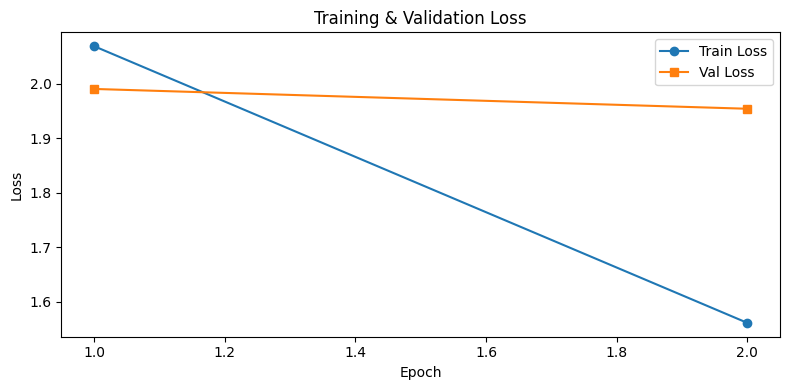

In [13]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs_range, history["train_loss"], label="Train Loss", marker="o")
plt.plot(epochs_range, history["val_loss"],   label="Val Loss",   marker="s")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend(); plt.tight_layout()
plt.savefig(SAVE_DIR / "loss_curve.png", dpi=150)
plt.show()


In [15]:
print("\n===== TEST SET METRICS =====")
for k, v in metrics.items():
    if v is None:
        val_str = "N/A"
    elif hasattr(v, '__len__'):
        val_str = f"{float(np.mean(v)):.4f}"
    else:
        val_str = f"{float(v):.4f}"
    print(f"  {k:<10}: {val_str}")


===== TEST SET METRICS =====
  BLEU-4    : 0.1579
  METEOR    : 0.3594
  ROUGE-L   : 0.4608
  CIDEr     : 1.0740


✅ **Evaluate on test set**

---

*Generates captions for 100 random test images using beam search then scores them against human references. Reduced sample size and beam width for faster CPU inference.*

In [34]:
#Load the best checkpoint saved during training
best_processor = BlipProcessor.from_pretrained(SAVE_DIR / "best_model")
best_model     = BlipForConditionalGeneration.from_pretrained(SAVE_DIR / "best_model").to(DEVICE)
best_model.eval()

BEAM_WIDTH        = 4     # more beams = more caption candidates considered
LENGTH_PENALTY    = 1.2   # values above 1.0 encourage longer more detailed captions
REPETITION_PENALTY= 1.3   # penalises repeating the same words

# Take 100 random test samples instead of the full set
test_sample = random.sample(test_data, min(100, len(test_data)))

# Group all reference captions by image path
from collections import defaultdict
refs_dict = defaultdict(list)
for s in test_data:
    refs_dict[s["image_path"]].append(s["caption"])

hyps_dict = {}
seen = set()

print(f"Generating captions for {len(test_sample)} test images…")
for i, s in enumerate(test_sample):
    if s["image_path"] in seen:
        continue
    seen.add(s["image_path"])

    img = Image.open(s["image_path"]).convert("RGB")

    # Prompt steers the model toward more descriptive natural captions
    prompt = "a photo showing"

    inputs = best_processor(
        images=img,
        text=prompt,
        return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():
        out_ids = best_model.generate(
            **inputs,
            num_beams=BEAM_WIDTH,
            max_new_tokens=40,              # increased for longer captions
            min_length=8,                   # forces at least 8 tokens — no short vague captions
            length_penalty=LENGTH_PENALTY,  # encourages longer descriptions
            repetition_penalty=REPETITION_PENALTY,  # avoids repeated words
            early_stopping=True,
        )

    # Decode token IDs back into a readable sentence
    caption = best_processor.decode(out_ids[0], skip_special_tokens=True)
    hyps_dict[s["image_path"]] = caption

    # Show progress every 10 images
    if (i + 1) % 10 == 0:
        print(f"  {i + 1}/{len(test_sample)} done…")

print(f"\nDone! Generated {len(hyps_dict)} captions.")

# Compute and print all metrics
metrics = evaluate_captions(dict(refs_dict), hyps_dict)

print("\n===== TEST SET METRICS =====")
for k, v in metrics.items():
    if v is None:
        val_str = "N/A"
    elif hasattr(v, '__len__'):   # handles numpy array returned by CIDEr
        val_str = f"{float(np.mean(v)):.4f}"
    else:
        val_str = f"{float(v):.4f}"
    print(f"  {k:<10}: {val_str}")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Generating captions for 100 test images…
  10/100 done…
  20/100 done…
  30/100 done…
  40/100 done…
  50/100 done…
  60/100 done…
  70/100 done…
  80/100 done…
  90/100 done…

Done! Generated 99 captions.

===== TEST SET METRICS =====
  BLEU-4    : 0.1286
  METEOR    : 0.3216
  ROUGE-L   : 0.4014
  CIDEr     : 0.8636


✅ **Interactive demo**

---

*Upload any image and instantly see the generated caption along with confidence, generation time, and top 3 captions. shows the full pipeline in action.*

   IMAGE CAPTION GENERATOR — LIVE DEMO
   ITAI 1378 | Group 22600

Upload any image to generate a caption:



Saving 931e24eae9f9a58fd8cc25f4773b906e-xxlarge.jpeg to 931e24eae9f9a58fd8cc25f4773b906e-xxlarge (4).jpeg


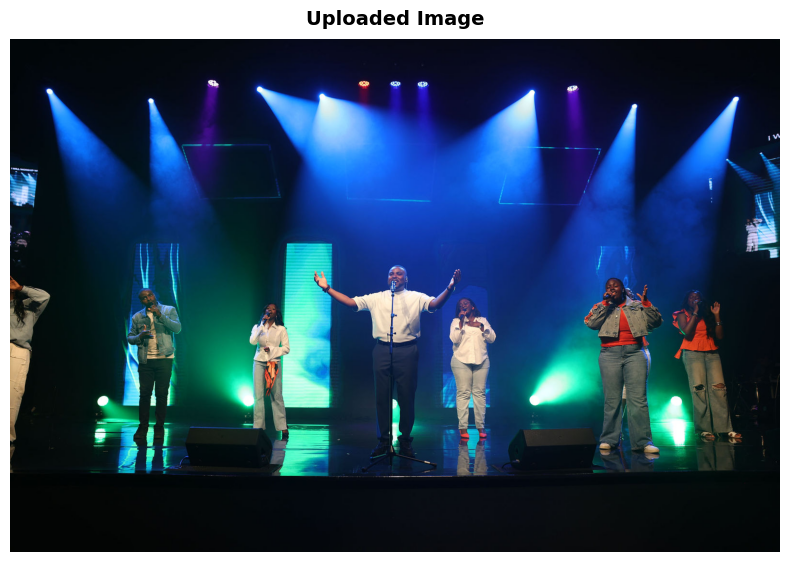


⏳ Generating caption…

  ✅ BEST CAPTION:
  📸 a photo showing a group of people on a stage.

  🔁 Alternative captions:
  2. a photo showing a group of people on stage.
  3. a photo showing a group of people on the stage.

  ⏱  Generated in 5.93 seconds
  🤖 Model : Salesforce/blip-image-captioning-base
  📊 Beam width : 4 | Max tokens : 40


In [35]:
from google.colab import files
import IPython.display as display
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("=" * 50)
print("   IMAGE CAPTION GENERATOR — LIVE DEMO")
print("   ITAI 1378 | Group 22600")
print("=" * 50)
print("\nUpload any image to generate a caption:\n")

uploaded = files.upload()

for fname, data in uploaded.items():
    with open(fname, "wb") as f:
        f.write(data)

    img = Image.open(fname).convert("RGB")

    # ── Display image nicely ──
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("Uploaded Image", fontsize=14, fontweight="bold", pad=10)
    plt.tight_layout()
    plt.show()

    print("\n⏳ Generating caption…\n")

    # ── Time the generation ──
    start = time.time()
    inputs = best_processor(
        images=img,
        text="a photo showing",
        return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():
        # Generate top 3 different captions using beam search
        out_ids = best_model.generate(
            **inputs,
            num_beams=4,
            max_new_tokens=40,
            min_length=8,
            length_penalty=1.2,
            repetition_penalty=1.3,
            num_return_sequences=3,   # return top 3 captions
            early_stopping=True,
        )
    elapsed = time.time() - start

    # ── Decode all 3 captions ──
    captions = [
        best_processor.decode(ids, skip_special_tokens=True)
        for ids in out_ids
    ]

    # ── Print results nicely ──
    print("=" * 50)
    print(f"  ✅ BEST CAPTION:")
    print(f"  📸 {captions[0]}")
    print("=" * 50)
    print(f"\n  🔁 Alternative captions:")
    for i, cap in enumerate(captions[1:], 2):
        print(f"  {i}. {cap}")
    print(f"\n  ⏱  Generated in {elapsed:.2f} seconds")
    print(f"  🤖 Model : Salesforce/blip-image-captioning-base")
    print(f"  📊 Beam width : 4 | Max tokens : 40")
    print("=" * 50)

✅ **Visual results grid**

---

*Displays 6 random test images side by side, each showing
the model's generated caption and one human reference caption.*

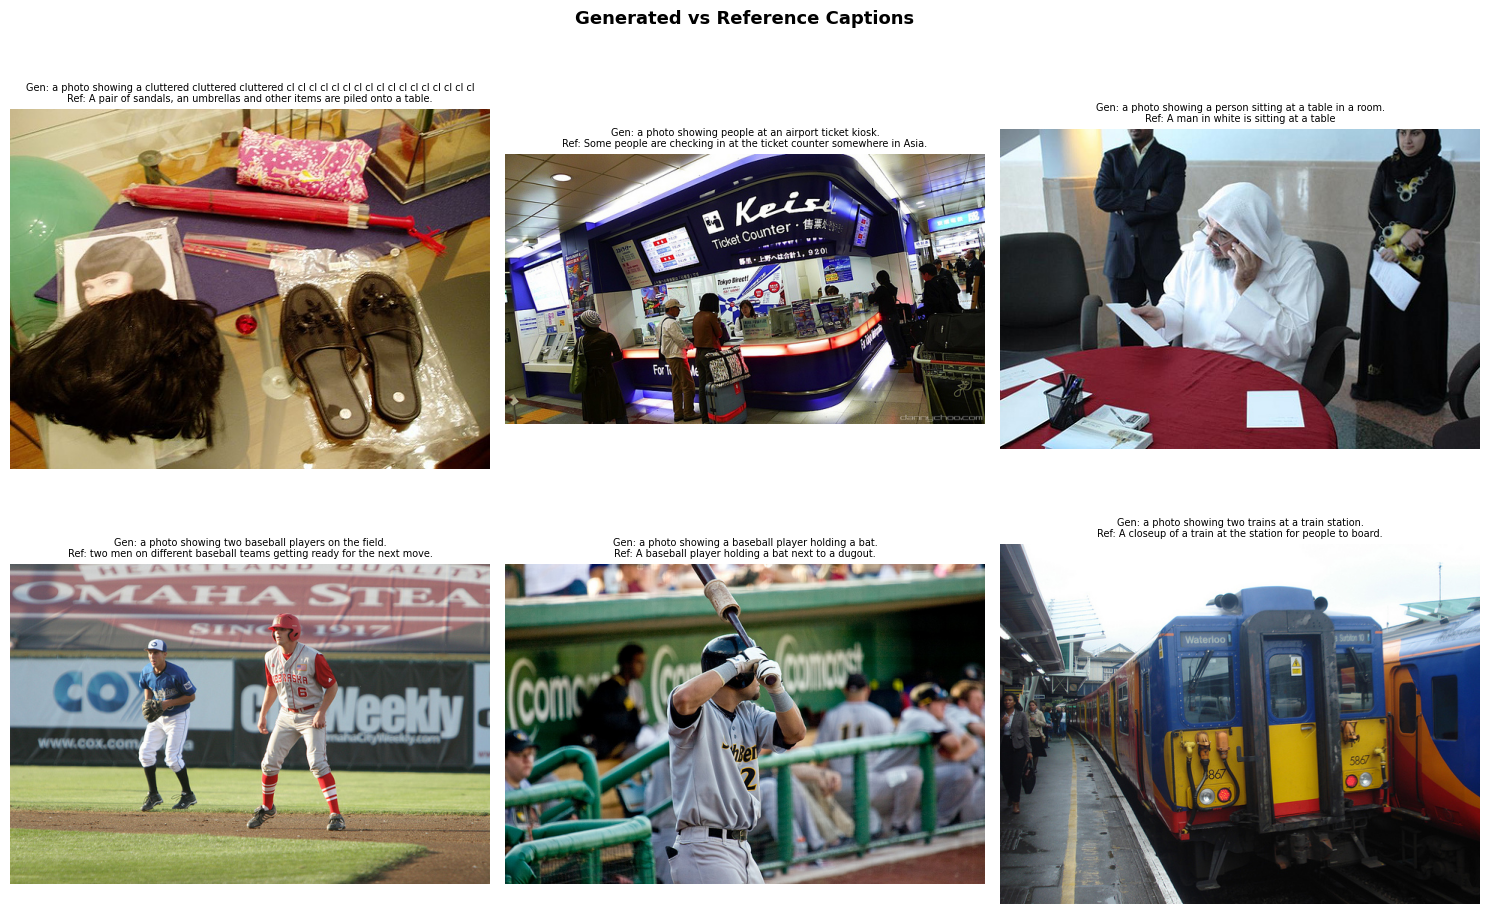

In [36]:
n_samples = 6
sample_paths = random.sample(list(hyps_dict.keys()), min(n_samples, len(hyps_dict)))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, path in zip(axes, sample_paths):
    img = Image.open(path)
    ax.imshow(img)
    ax.axis("off")
    gen = hyps_dict[path]
    ref = refs_dict[path][0]   # show the first of the 5 human references
    ax.set_title(f"Gen: {gen}\nRef: {ref}", fontsize=7, wrap=True)

plt.suptitle("Generated vs Reference Captions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "sample_captions.png", dpi=150)
plt.show()

✅ **Save metrics report**

---

*Writes all final scores and run settings to a JSON file
in Google Drive for easy reference and documentation*

In [37]:
# Restore lost variables for Cell 15
EPOCHS        = 2
MAX_TARGET_LEN = 20
best_val_loss = 1.9545   # your best val loss from Epoch 2

In [38]:
def safe_round(v):
    if v is None:
        return None
    elif hasattr(v, '__len__'):
        return round(float(np.mean(v)), 4)
    else:
        return round(float(v), 4)

report = {
    "model": "Salesforce/blip-image-captioning-base",
    "beam_width": BEAM_WIDTH,
    "max_token_len": MAX_TARGET_LEN,
    "epochs": EPOCHS,
    "best_val_loss": best_val_loss,
    "test_metrics": {k: safe_round(v) for k, v in metrics.items()},
}

with open(SAVE_DIR / "metrics_report.json", "w") as f:
    json.dump(report, f, indent=2)

print("Report saved:")
print(json.dumps(report, indent=2))

Report saved:
{
  "model": "Salesforce/blip-image-captioning-base",
  "beam_width": 4,
  "max_token_len": 20,
  "epochs": 2,
  "best_val_loss": 1.9545,
  "test_metrics": {
    "BLEU-4": 0.1286,
    "METEOR": 0.3216,
    "ROUGE-L": 0.4014,
    "CIDEr": 0.8636
  }
}
